In [ ]:
from pathlib import Path


def find_step1_root():
    current_dir = Path.cwd()
    for path in [current_dir, *current_dir.parents]:
        if path.name == "step1":
            return path
        if (path / "step1").is_dir():
            return path / "step1"
    return current_dir


STEP1_ROOT = find_step1_root()
DATA_DIR = STEP1_ROOT / "data"
OUTPUT_DIR = STEP1_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"STEP1_ROOT: {STEP1_ROOT}")

In [4]:
# =========================================================
# credit_card_transactions.csv 파일 읽기 및 CSV 로딩
# =========================================================

# 필요한 라이브러리 설치
# !pip install pandas

import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# 1. CSV 파일 로딩
# ---------------------------------------------------------

csv_path = DATA_DIR / "credit_card_transactions.csv"

df = pd.read_csv(csv_path)

print("CSV 로딩 완료")

# ---------------------------------------------------------
# 2. 기본 데이터 확인
# ---------------------------------------------------------

print("\n===== 데이터 상위 5개 =====")
print(df.head())

print("\n===== 데이터 정보 =====")
print(df.info())

print("\n===== 결측치 확인 =====")
print(df.isnull().sum())

print("\n===== 기술 통계 =====")
print(df.describe())

# ---------------------------------------------------------
# 3. 날짜 컬럼 변환
# ---------------------------------------------------------

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

print("\n날짜 변환 완료")

# ---------------------------------------------------------
# 4. 분석용 컬럼 추가
# ---------------------------------------------------------

df["year"] = df["trans_date_trans_time"].dt.year
df["month"] = df["trans_date_trans_time"].dt.month
df["day"] = df["trans_date_trans_time"].dt.day
df["hour"] = df["trans_date_trans_time"].dt.hour
df["weekday"] = df["trans_date_trans_time"].dt.day_name()

print("\n분석 컬럼 생성 완료")

# ---------------------------------------------------------
# 5. 기본 거래 분석
# ---------------------------------------------------------

print("\n===== 총 거래 건수 =====")
print(len(df))

print("\n===== 총 거래 금액 =====")
print(df["amt"].sum())

print("\n===== 평균 거래 금액 =====")
print(df["amt"].mean())

print("\n===== 최대 거래 금액 =====")
print(df["amt"].max())

print("\n===== 최소 거래 금액 =====")
print(df["amt"].min())


CSV 로딩 완료

===== 데이터 상위 5개 =====
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      long city_pop  \
0    Banks      F                561 Perry Cove  ...  -81.1781     3495   
1     Gill      F  4303


[TOP 10 고액 소비 고객]
                      총소비금액     평균소비금액  거래횟수  사기거래횟수      사기비율
cc_num                                                        
6011367958204270  296436.73  95.317277  3110       0  0.000000
4908846471916297  290478.49  95.583577  3039       3  0.000987
6011438889172900  284013.50  91.440277  3106      14  0.004507
36722699017270    280008.05  89.774944  3119       7  0.002244
6011893664860915  278325.97  90.073129  3090       0  0.000000
6011109736646996  278139.27  89.693412  3101       2  0.000645
3583635130604947  278042.99  91.884663  3026       0  0.000000
2712209726293386  277085.65  90.432653  3064       0  0.000000
4836998673805450  275930.63  91.156468  3027       4  0.001321
372509258176510   275889.68  90.337158  3054       8  0.002620


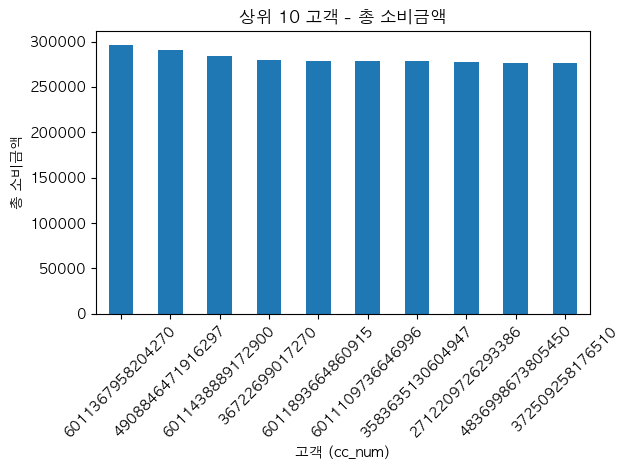

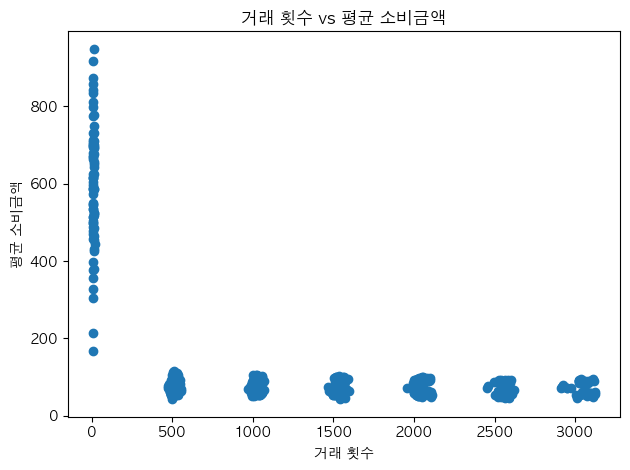

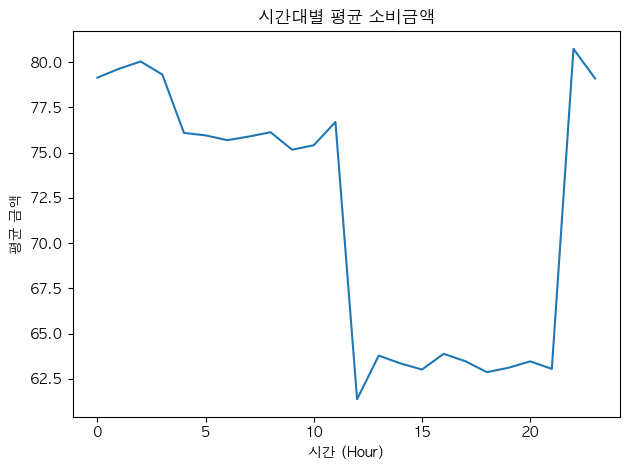

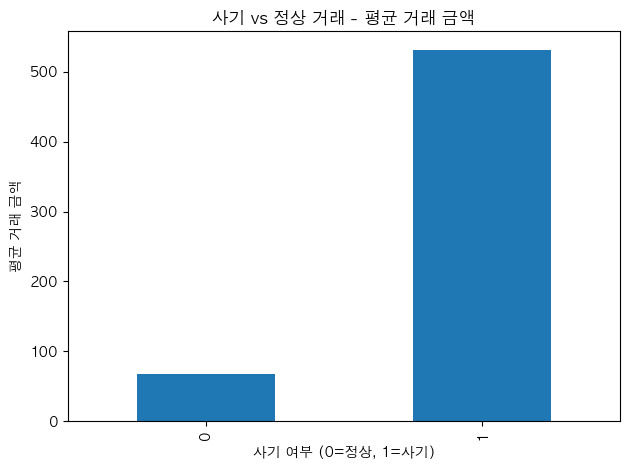

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 한글 폰트 설정 (중요)
# =========================
plt.rcParams["font.family"] = "AppleGothic"  # Windows 기준
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 깨짐 방지

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv(DATA_DIR / "credit_card_transactions.csv")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day_name()

# =========================
# 2. 고객 단위 행동 분석
# =========================
customer_group = df.groupby("cc_num")


customer_behavior = customer_group.agg(
    총소비금액=("amt", "sum"),
    평균소비금액=("amt", "mean"),
    거래횟수=("amt", "count"),
    사기거래횟수=("is_fraud", "sum"),
)

customer_behavior["사기비율"] = (
    customer_behavior["사기거래횟수"] / customer_behavior["거래횟수"]
)

# =========================
# 3. 상위 소비 고객 TOP 10
# =========================
top_spenders = customer_behavior.sort_values("총소비금액", ascending=False).head(10)

print("\n[TOP 10 고액 소비 고객]")
print(top_spenders)

# =========================
# 4. 시각화 1 - 고객별 총 소비
# =========================

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
top_spenders["총소비금액"].plot(kind="bar")
plt.title("상위 10 고객 - 총 소비금액")
plt.xlabel("고객 (cc_num)")
plt.ylabel("총 소비금액")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 5. 시각화 2 - 거래 횟수 vs 평균 금액
# =========================

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
plt.scatter(
    customer_behavior["거래횟수"],
    customer_behavior["평균소비금액"]
)
plt.title("거래 횟수 vs 평균 소비금액")
plt.xlabel("거래 횟수")
plt.ylabel("평균 소비금액")
plt.tight_layout()
plt.show()

# =========================
# 6. 시간대별 소비 패턴
# =========================
hourly_spend = df.groupby("hour")["amt"].mean()

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
hourly_spend.plot(kind="line")
plt.title("시간대별 평균 소비금액")
plt.xlabel("시간 (Hour)")
plt.ylabel("평균 금액")
plt.tight_layout()
plt.show()

# =========================
# 7. 사기 vs 정상 거래 비교
# =========================
fraud_group = df.groupby("is_fraud")["amt"].mean()

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
fraud_group.plot(kind="bar")
plt.title("사기 vs 정상 거래 - 평균 거래 금액")
plt.xlabel("사기 여부 (0=정상, 1=사기)")
plt.ylabel("평균 거래 금액")
plt.tight_layout()
plt.show()


[TOP 10 고액 소비 고객]
                      총소비금액     평균소비금액  거래횟수  사기거래횟수      사기비율
cc_num                                                        
6011367958204270  296436.73  95.317277  3110       0  0.000000
4908846471916297  290478.49  95.583577  3039       3  0.000987
6011438889172900  284013.50  91.440277  3106      14  0.004507
36722699017270    280008.05  89.774944  3119       7  0.002244
6011893664860915  278325.97  90.073129  3090       0  0.000000
6011109736646996  278139.27  89.693412  3101       2  0.000645
3583635130604947  278042.99  91.884663  3026       0  0.000000
2712209726293386  277085.65  90.432653  3064       0  0.000000
4836998673805450  275930.63  91.156468  3027       4  0.001321
372509258176510   275889.68  90.337158  3054       8  0.002620


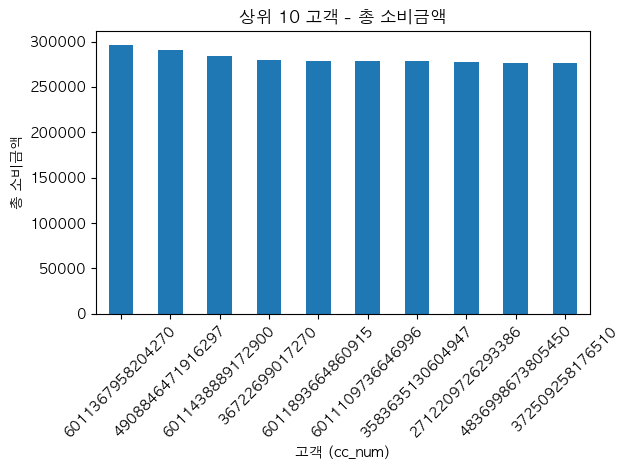

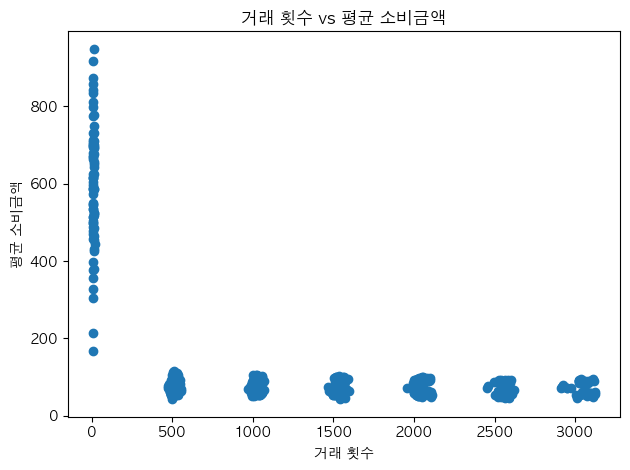

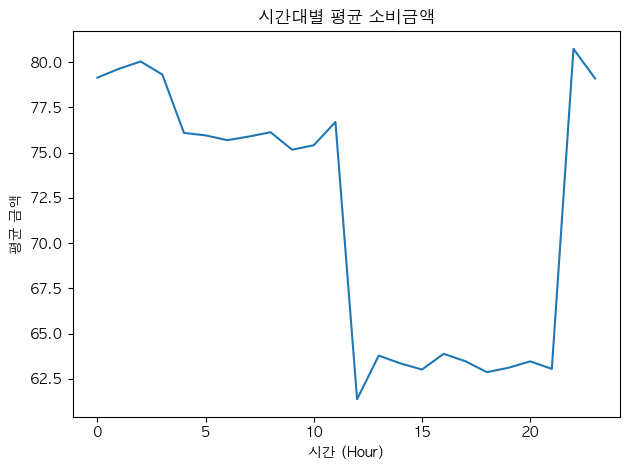

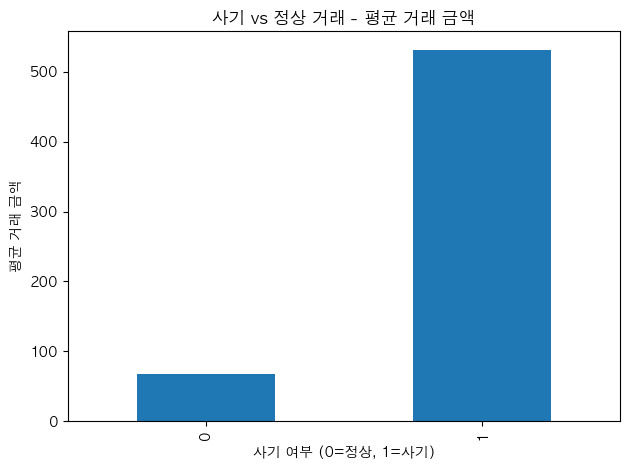

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 한글 폰트 설정 (중요)
# =========================
plt.rcParams["font.family"] = "AppleGothic" 
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 깨짐 방지

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv(DATA_DIR / "credit_card_transactions.csv")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day_name()

# =========================
# 2. 고객 단위 행동 분석
# =========================
customer_group = df.groupby("cc_num")


customer_behavior = customer_group.agg(
    총소비금액=("amt", "sum"),
    평균소비금액=("amt", "mean"),
    거래횟수=("amt", "count"),
    사기거래횟수=("is_fraud", "sum"),
)

customer_behavior["사기비율"] = (
    customer_behavior["사기거래횟수"] / customer_behavior["거래횟수"]
)

# =========================
# 3. 상위 소비 고객 TOP 10
# =========================
top_spenders = customer_behavior.sort_values("총소비금액", ascending=False).head(10)

print("\n[TOP 10 고액 소비 고객]")
print(top_spenders)

# =========================
# 4. 시각화 1 - 고객별 총 소비
# =========================

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
top_spenders["총소비금액"].plot(kind="bar")
plt.title("상위 10 고객 - 총 소비금액")
plt.xlabel("고객 (cc_num)")
plt.ylabel("총 소비금액")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 5. 시각화 2 - 거래 횟수 vs 평균 금액
# =========================

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
plt.scatter(
    customer_behavior["거래횟수"],
    customer_behavior["평균소비금액"]
)
plt.title("거래 횟수 vs 평균 소비금액")
plt.xlabel("거래 횟수")
plt.ylabel("평균 소비금액")
plt.tight_layout()
plt.show()

# =========================
# 6. 시간대별 소비 패턴
# =========================
hourly_spend = df.groupby("hour")["amt"].mean()

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
hourly_spend.plot(kind="line")
plt.title("시간대별 평균 소비금액")
plt.xlabel("시간 (Hour)")
plt.ylabel("평균 금액")
plt.tight_layout()
plt.show()

# =========================
# 7. 사기 vs 정상 거래 비교
# =========================
fraud_group = df.groupby("is_fraud")["amt"].mean()

#새로운 그래프 영역(캔버스)을 생성
plt.figure()
fraud_group.plot(kind="bar")
plt.title("사기 vs 정상 거래 - 평균 거래 금액")
plt.xlabel("사기 여부 (0=정상, 1=사기)")
plt.ylabel("평균 거래 금액")
plt.tight_layout()
plt.show()